In [1]:
#
# 1
#
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time

# Fonction pour récupérer le contenu HTML d'une page donnée
def get_page_html(url):
    response = requests.get(url)
    if response.status_code == 200:
        return response.text
    else:
        print(f"Erreur lors de la récupération de la page {url}")
        get_page_html(url)
        return None

# Fonction pour extraire les liens des fiches depuis une page
def extract_article_links(page_html, letter):
    soup = BeautifulSoup(page_html, 'html.parser')
    liste_articles_div = soup.find('div', class_='liste-articles')
    
    if liste_articles_div:
        links = liste_articles_div.find_all('a', href=lambda href: href and 'spip.php?article' in href)
        return [(link['href'], link.text, letter) for link in links]
    else:
        print(f"La balise <div class='liste-articles'> n'a pas été trouvée sur la page de la lettre {letter}.")
        return []

# Fonction pour récupérer le HTML d'une fiche donnée
def get_article_html(article_url):
    full_url = 'https://fusilles-40-44.maitron.fr/' + article_url
    time.sleep(10)  # Temporisation de 10 secondes entre chaque requête
    return get_page_html(full_url)

# Fonction principale pour parcourir les pages A, B, C, ...
def main():
    base_url = 'https://fusilles-40-44.maitron.fr/spip.php?mot10754&lettre='
    letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    
    for letter in letters:
        page_url = base_url + '^[' + letter.lower() + letter.upper() + ']'
        page_html = get_page_html(page_url)
        
        if page_html:
            article_links = extract_article_links(page_html, letter)
            
            for i, (article_link, person_name, letter) in enumerate(article_links):
                print(f"Traitement de la fiche {i + 1} pour la lettre {letter} - Personne : {person_name}.")
                article_html = get_article_html(article_link)
                
                if article_html:
                    # Stocker le résultat dans la liste
                    result_list.append((person_name, article_link, article_html))
                    
                    # Afficher un message indiquant que la fiche a été récupérée avec succès
                    print(f"Fiche {i + 1} pour la lettre {letter} récupérée avec succès.\n")
                else:
                    print(f"Erreur lors de la récupération de la fiche {i + 1} pour la lettre {letter}.\n")
        
        # Ajouter une ligne pour indiquer la fin du traitement de la lettre
        print(f"Fin du traitement pour la lettre {letter}.\n{'='*50}\n")

# Dictionnaire pour stocker les résultats
result_list = []

# Fonction principale
main()

# Convertir la liste en DataFrame
df = pd.DataFrame(result_list, columns=['person_name', 'article_url', 'letter'])
#df.reset_index(drop=True, inplace=True)
df.head()
    


Traitement de la fiche 1 pour la lettre A - Personne : ABALAIN Albert, Corentin, Hervé.
Fiche 1 pour la lettre A récupérée avec succès.

Traitement de la fiche 2 pour la lettre A - Personne : ABARRATEGUI François, Benoît. Écrit parfois par erreur ABARRETEGUY François.
Fiche 2 pour la lettre A récupérée avec succès.

Traitement de la fiche 3 pour la lettre A - Personne : AILLOT Claude.
Fiche 3 pour la lettre A récupérée avec succès.

Traitement de la fiche 4 pour la lettre A - Personne : ALEZARD Jean, Léon [ALÉZARD] [Pseudonymes : Gil André, Lescaut, Lemoine, Bassecourt].
Fiche 4 pour la lettre A récupérée avec succès.

Traitement de la fiche 5 pour la lettre A - Personne : ALFONSO Celestino.
Fiche 5 pour la lettre A récupérée avec succès.

Traitement de la fiche 6 pour la lettre A - Personne : ALIÉMART Gilbert, Timothée [dit Roussel].
Fiche 6 pour la lettre A récupérée avec succès.

Traitement de la fiche 7 pour la lettre A - Personne : ANQUETIL Bernard, Jules, Eugène alias Lhermite .


,person_name,article_url,letter
0,"ABALAIN Albert, Corentin, Hervé",spip.php?article142667&id_mot=10754,<!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 S...
1,"ABARRATEGUI François, Benoît. Écrit parfois pa...",spip.php?article88754&id_mot=10754,<!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 S...
2,AILLOT Claude,spip.php?article9748&id_mot=10754,<!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 S...
3,"ALEZARD Jean, Léon [ALÉZARD] [Pseudonymes : Gi...",spip.php?article9847&id_mot=10754,<!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 S...
4,ALFONSO Celestino,spip.php?article9851&id_mot=10754,<!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 S...


In [2]:
#
# 2
#
df.to_csv('Raw Maitron 40-44 Letters.csv', index=False)

In [125]:
#
# 3
#
#new_df = df.copy()
new_df = pd.read_csv('Raw Maitron 40-44 Letters.csv')  

def select_html_letter(html_text):
    soup = BeautifulSoup(html_text, 'html.parser')
    blockquote = soup.find('blockquote', class_='spip_poesie')  # Première occurrence

    # Vérifier si le blockquote existe avant d'extraire le texte
    if blockquote:
        text = blockquote.get_text()
        return text
    else:
        blockquote = soup.find('blockquote', class_='spip')  # Première occurrence
        if blockquote:
            text = blockquote.get_text()
            return text
        else:
            text = ""
            return text

new_df['letter'] = new_df['letter'].apply(select_html_letter)

new_df.to_csv('Raw Maitron 40-44 Letters (2).csv', index=False)

In [126]:
#
# 4
#
'''
COLIN Pierre - fait
JACQ Fernand, Joseph - pas ocr dispo sur le Maitron
LAGADIC Louis, Noël, Marie - pas ocr dispo sur le Maitron
LAGUERRE François, Joseph - fait
LE PANSE Julien - pas ocr dispo sur le Maitron
LEFEBVRE Edmond, Désiré. Écrit parfois LEFEVRE Edmond - pas ocr dispo sur le Maitron
MARTIN Aloïs, Jacques - fait
MICHELS Charles - pas ocr dispo sur le Maitron
PÉDOT Edmond, Georges, Gaston - fait
PELLETIER François [Pseudonymes dans la Résistance : Ruben, PERRON François] - fait
PETIT (parfois orth. PETYT) Marcel, Corneille, Raphaël - pas ocr dispo sur le Maitron
PLANTADI Louis, dit "Loulou" [Pseudonyme : Radis], souvent nommé : "PLANTADIS" ou "PLANTADE" - pas ocr dispo sur le Maitron
QUARRÉ Jean - pas ocr dispo sur le Maitron
SOVEAUX André, Charles, Edmond - pas ocr dispo sur le Maitron
TARQUIN Edgar, Paul, Joseph - pas ocr dispo sur le Maitron
TELLIER Raymond, André - pas ocr dispo sur le Maitron
TROUSSEL Jacques, André - fait
'''
new_df.to_csv('Raw Maitron 40-44 Letters (3).csv', index=False)

In [198]:
#
# 5
#
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
import re
import nltk
import pandas as pd
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree
import spacy
from nltk.stem import WordNetLemmatizer
import nltk


# Télécharger les ressources éventuellement nécessaires
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

'''
# Modèle Spacy
nlp = spacy.load("fr_core_news_sm") 

# Fonction pour extraire la première entité géographique avec Spacy
def extract_first_location_spacy(text):
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["GPE", "LOC"] and "france" not in ent.text.lower():
            return ent.text
    return None


# Fonction pour extraire la première entité géographique avec NLTK
def extract_first_location_nltk(text):
    words = word_tokenize(text)
    tags = pos_tag(words)
    tree = ne_chunk(tags)

    for subtree in tree:
        if type(subtree) == Tree and (subtree.label() == 'GPE' or  subtree.label() == 'LOC'):
            gpe = " ".join(word for word, tag in subtree.leaves())
            if "france" not in gpe.lower():
                return gpe
    return None
'''

def clean_text(text):    
    # Supprimer les caractères non alphabétiques à l'exception des lettres accentuées
    text = re.sub(r"[^a-zA-ZàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ]", " ", text)
    
    # Convertir en minuscules
    text = text.lower()
    
    # Tokenization : diviser le texte en mots
    words = word_tokenize(text)
    
    # Supprimer les stop words
    stop_words = set(stopwords.words('french'))
    words = [word for word in words if word not in stop_words]
    
    # Créez un objet WordNetLemmatizer pour la lemmatisation
    lemmatizer = WordNetLemmatizer()

    # Créez un objet SnowballStemmer pour la racinisation (stemming)
    stemmer = SnowballStemmer('french')

    # Lemmatisation de chaque mot
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]

    # Racinisation (stemming) des mots lemmatisés
    #stemmed_words = [stemmer.stem(word) for word in lemmatized_words]

    # Reconstruire le texte après le nettoyage et la racinisation
    cleaned_text = ' '.join(lemmatized_words)
    
    return cleaned_text

new_df = pd.read_csv('Raw Maitron 40-44 Letters (3).csv')  
new_df.dropna(subset=['letter'], inplace=True)
new_df.reset_index(drop=True, inplace=True)
print(new_df['letter'].isna().sum())

new_df['letter'] = new_df['letter'].apply(clean_text)
#print(new_df.head(25))
new_df.to_csv('Raw Maitron 40-44 Letters (4).csv', index=False)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/benoitprieur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/benoitprieur/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/benoitprieur/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /Users/benoitprieur/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     /Users/benoitprieur/nltk_data...
[nltk_data]   Package words is already up-to-date!


0


In [199]:
#
# 6
#
new_df.info()
new_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   person_name  310 non-null    object
 1   article_url  310 non-null    object
 2   letter       310 non-null    object
dtypes: object(3)
memory usage: 7.4+ KB


,person_name,article_url,letter
count,310,310,310
unique,310,310,310
top,"ABALAIN Albert, Corentin, Hervé",spip.php?article142667&id_mot=10754,prison rennes mar très chers parent profite éc...
freq,1,1,1


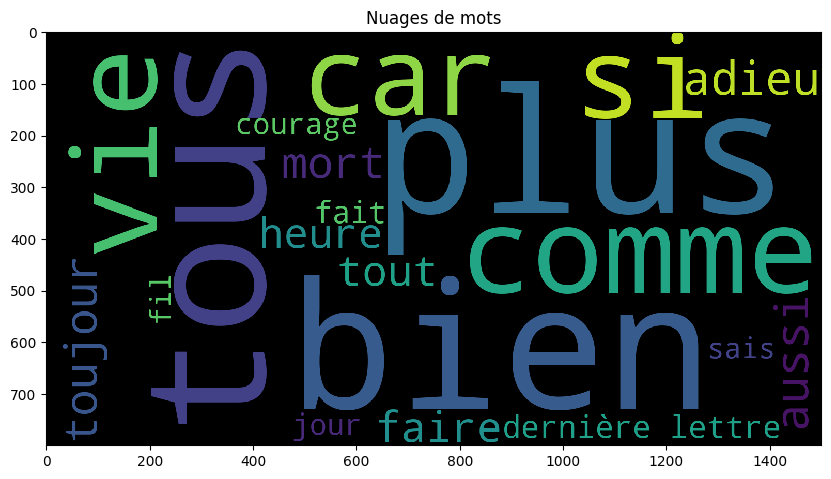

In [200]:
#
# 7
#
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize = (10,10)) 
wc = WordCloud(max_words = 20, width = 1500 , height = 800).generate(" ".join(new_df.letter))
plt.title("Nuages de mots")
plt.imshow(wc , interpolation = 'none')

In [201]:
######### KMEANS #########

In [202]:
#
# 8
#
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Prétraitement avec TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(new_df['letter'])

# Application de KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    n_init=100,
    max_iter=1000,  # Nombre maximum d'itérations
    tol=1e-4,       # Tolérance pour la convergence
    algorithm='lloyd',  # Variante de l'algorithme
    init='k-means++',  # Méthode d'initialisation
    verbose=0
)
kmeans.fit(tfidf_matrix)
new_df['cluster'] = kmeans.labels_

# Extraction des mots clés pour chaque cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()

for i in range(2):
    print("Cluster %d :" % i, end='')
    for ind in order_centroids[i, :15]:  # affiche les 20 mots-clés les plus importants pour chaque cluster
        print(' %s' % terms[ind], end='')
    print()

Cluster 0 : plus maman tous petite bien tout vie chérie papa adieu si être comme car petit
Cluster 1 : tous dernière bien adieu lettre mort parent chers être chère mourir france courage heures fils


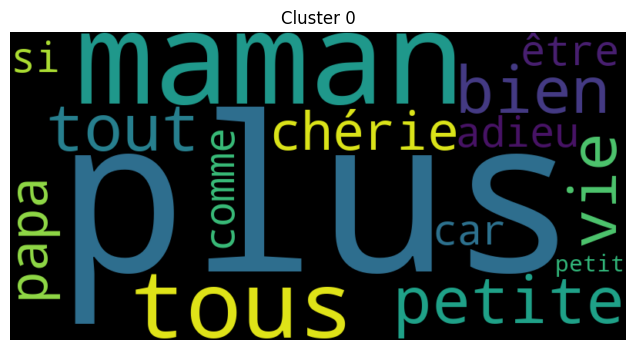

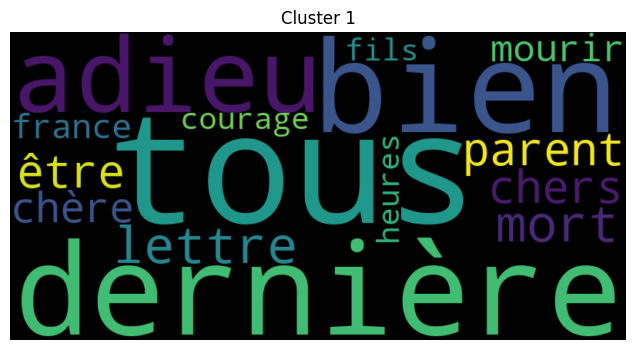

In [203]:
#
# 9
#
# Afficher les nuages de mots pour chaque cluster
for i in range(2):
    cluster_terms = [terms[ind] for ind in order_centroids[i, :15]]  # Les 15 mots-clés les plus importants pour chaque cluster
    wordcloud = WordCloud(width=800, height=400).generate(" ".join(cluster_terms))
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Cluster {i}')
    plt.axis("off")
    plt.show()

In [204]:
#
# 10
#
cluster_0_words = []
cluster_1_words = []

# Parcourir les 15 mots-clés les plus importants de chaque cluster
for ind in order_centroids[0, :15]:
    if (terms[ind] not in cluster_1_words):
        cluster_0_words.append(terms[ind])

for ind in order_centroids[1, :15]:
    if (terms[ind] not in cluster_0_words):
        cluster_1_words.append(terms[ind])

# Afficher les listes de mots épurés
print("Mots du Cluster 0 :", cluster_0_words)
print("Mots du Cluster 1 :", cluster_1_words)

Mots du Cluster 0 : ['plus', 'maman', 'tous', 'petite', 'bien', 'tout', 'vie', 'chérie', 'papa', 'adieu', 'si', 'être', 'comme', 'car', 'petit']
Mots du Cluster 1 : ['dernière', 'lettre', 'mort', 'parent', 'chers', 'chère', 'mourir', 'france', 'courage', 'heures', 'fils']


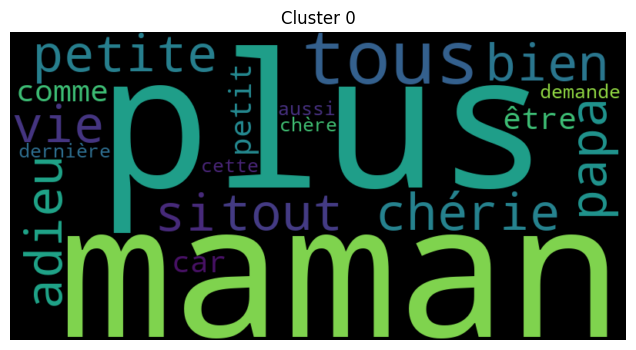

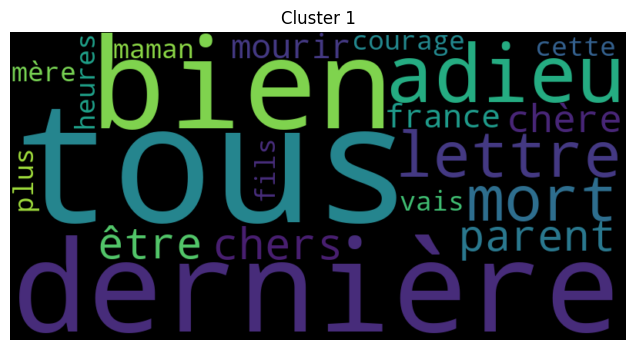

In [205]:
#
# 11
#
# Afficher les nuages de mots pour chaque cluster
for i in range(2):
    cluster_terms = [terms[ind] for ind in order_centroids[i, :20]]  # Les 10 mots-clés les plus importants pour chaque cluster
    wordcloud = WordCloud(width=800, height=400).generate(" ".join(cluster_terms))
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Cluster {i}')
    plt.axis("off")
    plt.show()

In [ ]:
######### LDA #########

In [208]:
#
# 12
#
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import models, corpora
import gensim

# Prétraitement avec TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(new_df['letter'])

# Convertir la matrice TF-IDF en format Gensim
corpus = gensim.matutils.Sparse2Corpus(tfidf_matrix.transpose())

# Créer un dictionnaire de mots
id2word = dict((v, k) for k, v in tfidf_vectorizer.vocabulary_.items())

# Appliquer le modèle LDA
lda_model = models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=2,  # Nombre de sujets/clusters
    random_state=0,
    iterations=1000,  # Nombre maximum d'itérations
    passes=100  # Nombre de passages sur les données
)

# Extraction des mots clés pour chaque sujet/cluster
for i, topic in lda_model.print_topics(num_topics=2, num_words=8):
    print(f"Cluster {i} : {topic}")

Cluster 0 : 0.002*"tous" + 0.002*"bien" + 0.002*"adieu" + 0.002*"maman" + 0.002*"plus" + 0.002*"dernière" + 0.002*"tout" + 0.002*"être"
Cluster 1 : 0.000*"chasseur" + 0.000*"collaborer" + 0.000*"gibier" + 0.000*"blot" + 0.000*"vaincre" + 0.000*"gaulle" + 0.000*"baisse" + 0.000*"généreuses"


In [ ]:
######### Word2Vec #########

In [215]:
#
# 13
#
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import gensim

# Prétraitement avec TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(new_df['letter'])

# Convertir la matrice TF-IDF en format Gensim
corpus = gensim.matutils.Sparse2Corpus(tfidf_matrix.transpose())

# Créer un dictionnaire de mots
id2word = dict((v, k) for k, v in tfidf_vectorizer.vocabulary_.items())

# Créer un modèle Word2Vec
word2vec_model = Word2Vec(
    sentences=new_df['letter'].apply(lambda x: x.split()),  # Assurez-vous que le texte est divisé en mots
    vector_size=250,  # Dimension des vecteurs de mots
    window=5,  # Taille de la fenêtre de contexte
    min_count=1,  # Nombre minimum d'occurrences d'un mot
    sg=0,  # Skip-gram (0 pour CBOW)
    workers=8  # Nombre de threads pour l'entraînement
)

for word in ['dieu', 'curé', 'adieu', 'mort', 'france', 'mourrir', 'résistance', 'allemand', 'communiste', "gaulle"]:
    print(f"Similar words to '{word}': {word2vec_model.wv.most_similar(word)}")

Similar words to 'dieu': [('a', 0.9999439120292664), ('comme', 0.9999369978904724), ('si', 0.9999358057975769), ('depuis', 0.9999352097511292), ('avoir', 0.9999346733093262), ('car', 0.9999344348907471), ('souvenir', 0.9999322295188904), ('toujours', 0.9999321699142456), ('où', 0.9999311566352844), ('aussi', 0.9999305605888367)]
Similar words to 'curé': [('bonheur', 0.9993031620979309), ('courage', 0.999300479888916), ('ainsi', 0.9992964863777161), ('trop', 0.9992941617965698), ('très', 0.9992897510528564), ('vie', 0.9992892146110535), ('aussi', 0.9992889165878296), ('père', 0.9992815852165222), ('plus', 0.9992791414260864), ('voir', 0.9992787837982178)]
Similar words to 'adieu': [('amis', 0.9998753666877747), ('ur', 0.9998722076416016), ('tous', 0.9998717904090881), ('aime', 0.9998466968536377), ('embrasse', 0.9998418688774109), ('fils', 0.9998318552970886), ('dis', 0.9998288154602051), ('ainsi', 0.9998270869255066), ('toute', 0.9998263120651245), ('papa', 0.9998260736465454)]
Similar